# MMCA literature analysis
This notebook contains source codes used to generate figures for iJCSCL article on systematic review of MMCA research field.

In [70]:
from mmcalib_cscw_v8dataset import LiteratureDataset
lit = LiteratureDataset('../dataset/updated/8.2024-duplicates-removed - Corpus(5).csv')

#data_ = lit.plot_trends('data',skip_values=['fnirs','bvp'], fig_title="Data usage over time",attribute_label="Data")

Populating with paper records ...
Literature dataset is succefully populated. 
  Total papers: 163


## General trends

### Publications over the years

In [72]:
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
# Fetch all papers
papers = lit.paper_store

years = list(range(1999,2026,1))
study_setting = {}


year_wise_papers = defaultdict(int)
study_setting['lab']=dict()
study_setting['eco']=dict()

sample_size = []
citations= dict()

for year in years:
    study_setting['lab'][year] = 0
    study_setting['eco'][year] = 0
    citations[year]= 0


for paper_id in papers:
    paper = papers[paper_id]
    pub_year = paper.get_pub_year()
    year_wise_papers[pub_year] += 1

    setting = paper.get_study_setting()

    if paper.citation != '':
        print(paper_id,' ',paper.citation)
        citations[pub_year] += float(paper.citation)
    else:
        print(paper.citation)

    try:
        sample_size.append(int(paper.sample_size))
    except:
        pass
    
    if setting == 'lab':
        study_setting['lab'][pub_year] += 1
    elif setting == 'eco':
        study_setting['eco'][pub_year] += 1
    else:
        print('Study setting issue:',paper_id)

1   158
2   55
3   98
4   25
5   38
6   58
7   14
8   51
9   43
10   29
11   92
12   33
13   2
14   5
15   106
16   15
17   27
18   81
19   62
20   8
21   114
22   26
23   38
24   27
25   86
26   7
27   110
28   118
29   67
30   35
31   65
32   14
33   22
34   21
35   97
36   32
37   58
38   42
39   44
40   26
41   1
42   106
Study setting issue: 42
43   11
44   52
45   169
46   55
47   48
48   16
49   37
50   24
51   213
52   13
53   44
54   28
55   26
56   48
57   31
58   40
59   20
60   47
61   149
62   641
63   27
64   16
65   11
66   21
67   39
68   59
69   40
70   68
71   36
73   101
74   43
75   213
76   11
77   14
78   19
79   58
80   21
81   50
82   0
83   8
84   29
86   823
87   13
88   106
89   46
90   28
91   118
92   27
94   36
95   2
96   89
97   561
98   123
99   451
100   29
101   137
102   64
103   120
104   26
105   127
106   618
107   4
108   30
109   13
110   22
111   216
112   48
113   28
114   14
115   11
116   47
117   98
119   30
121   212
122   17
123   32
124 

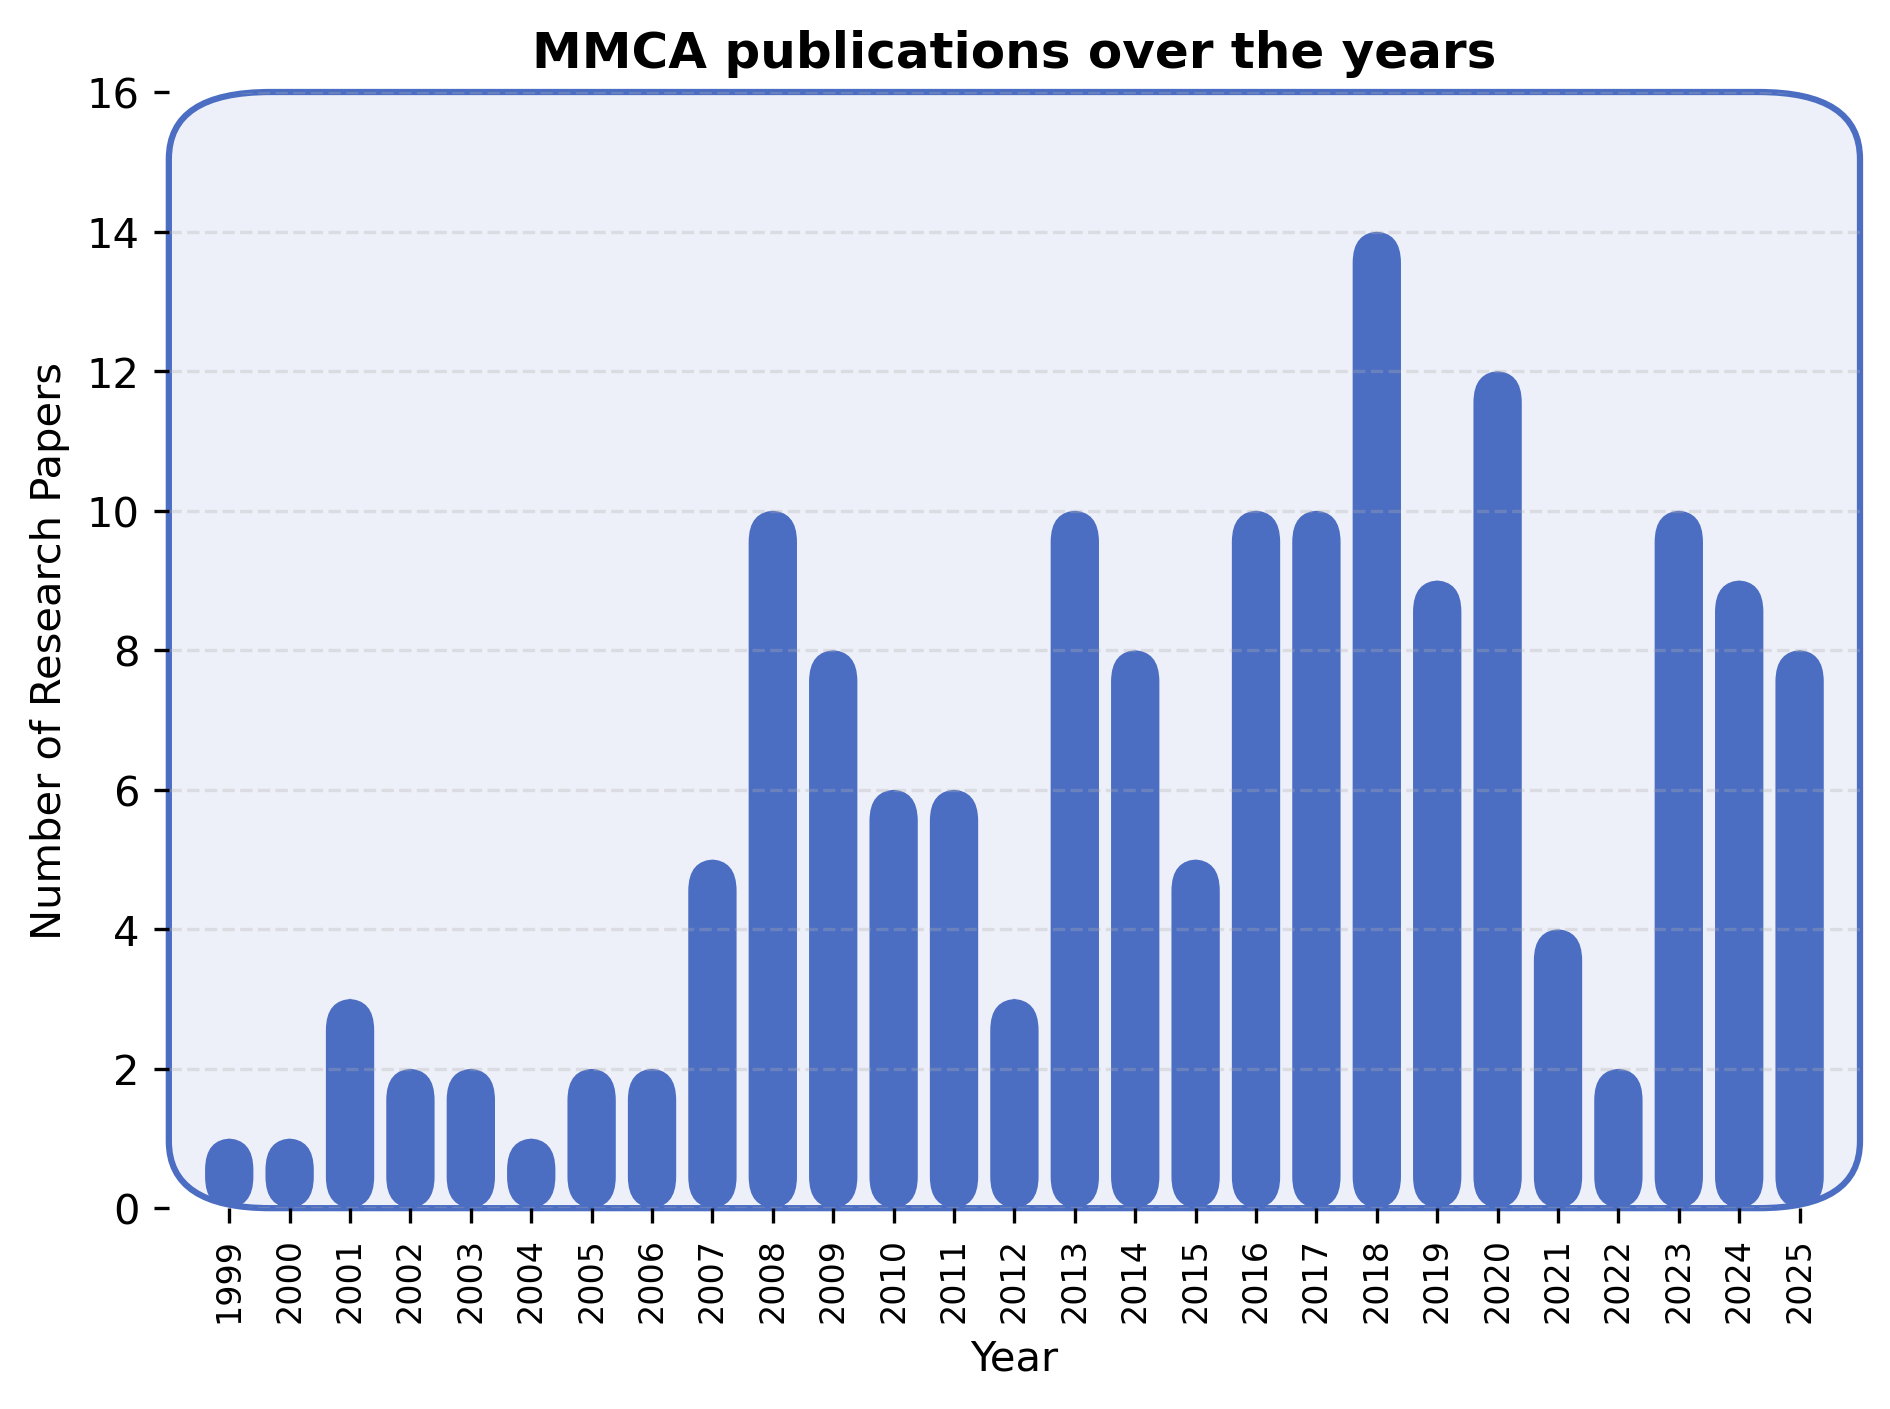

In [74]:
data = year_wise_papers

# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

fig_title = "MMCA publications over the years"

# Create the plot
fig, ax = plt.subplots(dpi=300,subplot_kw={'projection': 'fancy_box_axes'})
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)
ax.set_facecolor('#EEF0F9')

bar_width = 0.8
bar_color = '#4B6DC2'

# Plot each bar with rounded corners
for i, (year, count) in enumerate(zip(years, counts)):
    rect = FancyBboxPatch(
        (i - bar_width / 2, 0),  # bottom-left corner
        bar_width,
        count,
        boxstyle="round,pad=0,rounding_size=.45",
        linewidth=0,
        facecolor=bar_color
    )
    ax.add_patch(rect)

# Set limits and ticks
ax.set_xlim(-1, len(years))
ax.set_ylim(0, max(counts) + 2)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=90, fontsize=8)

# Labels and grid
ax.set_title(fig_title, fontsize=12, fontweight='bold')
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Number of Research Papers", fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{fig_title}.png',format='png')

### Study settings 


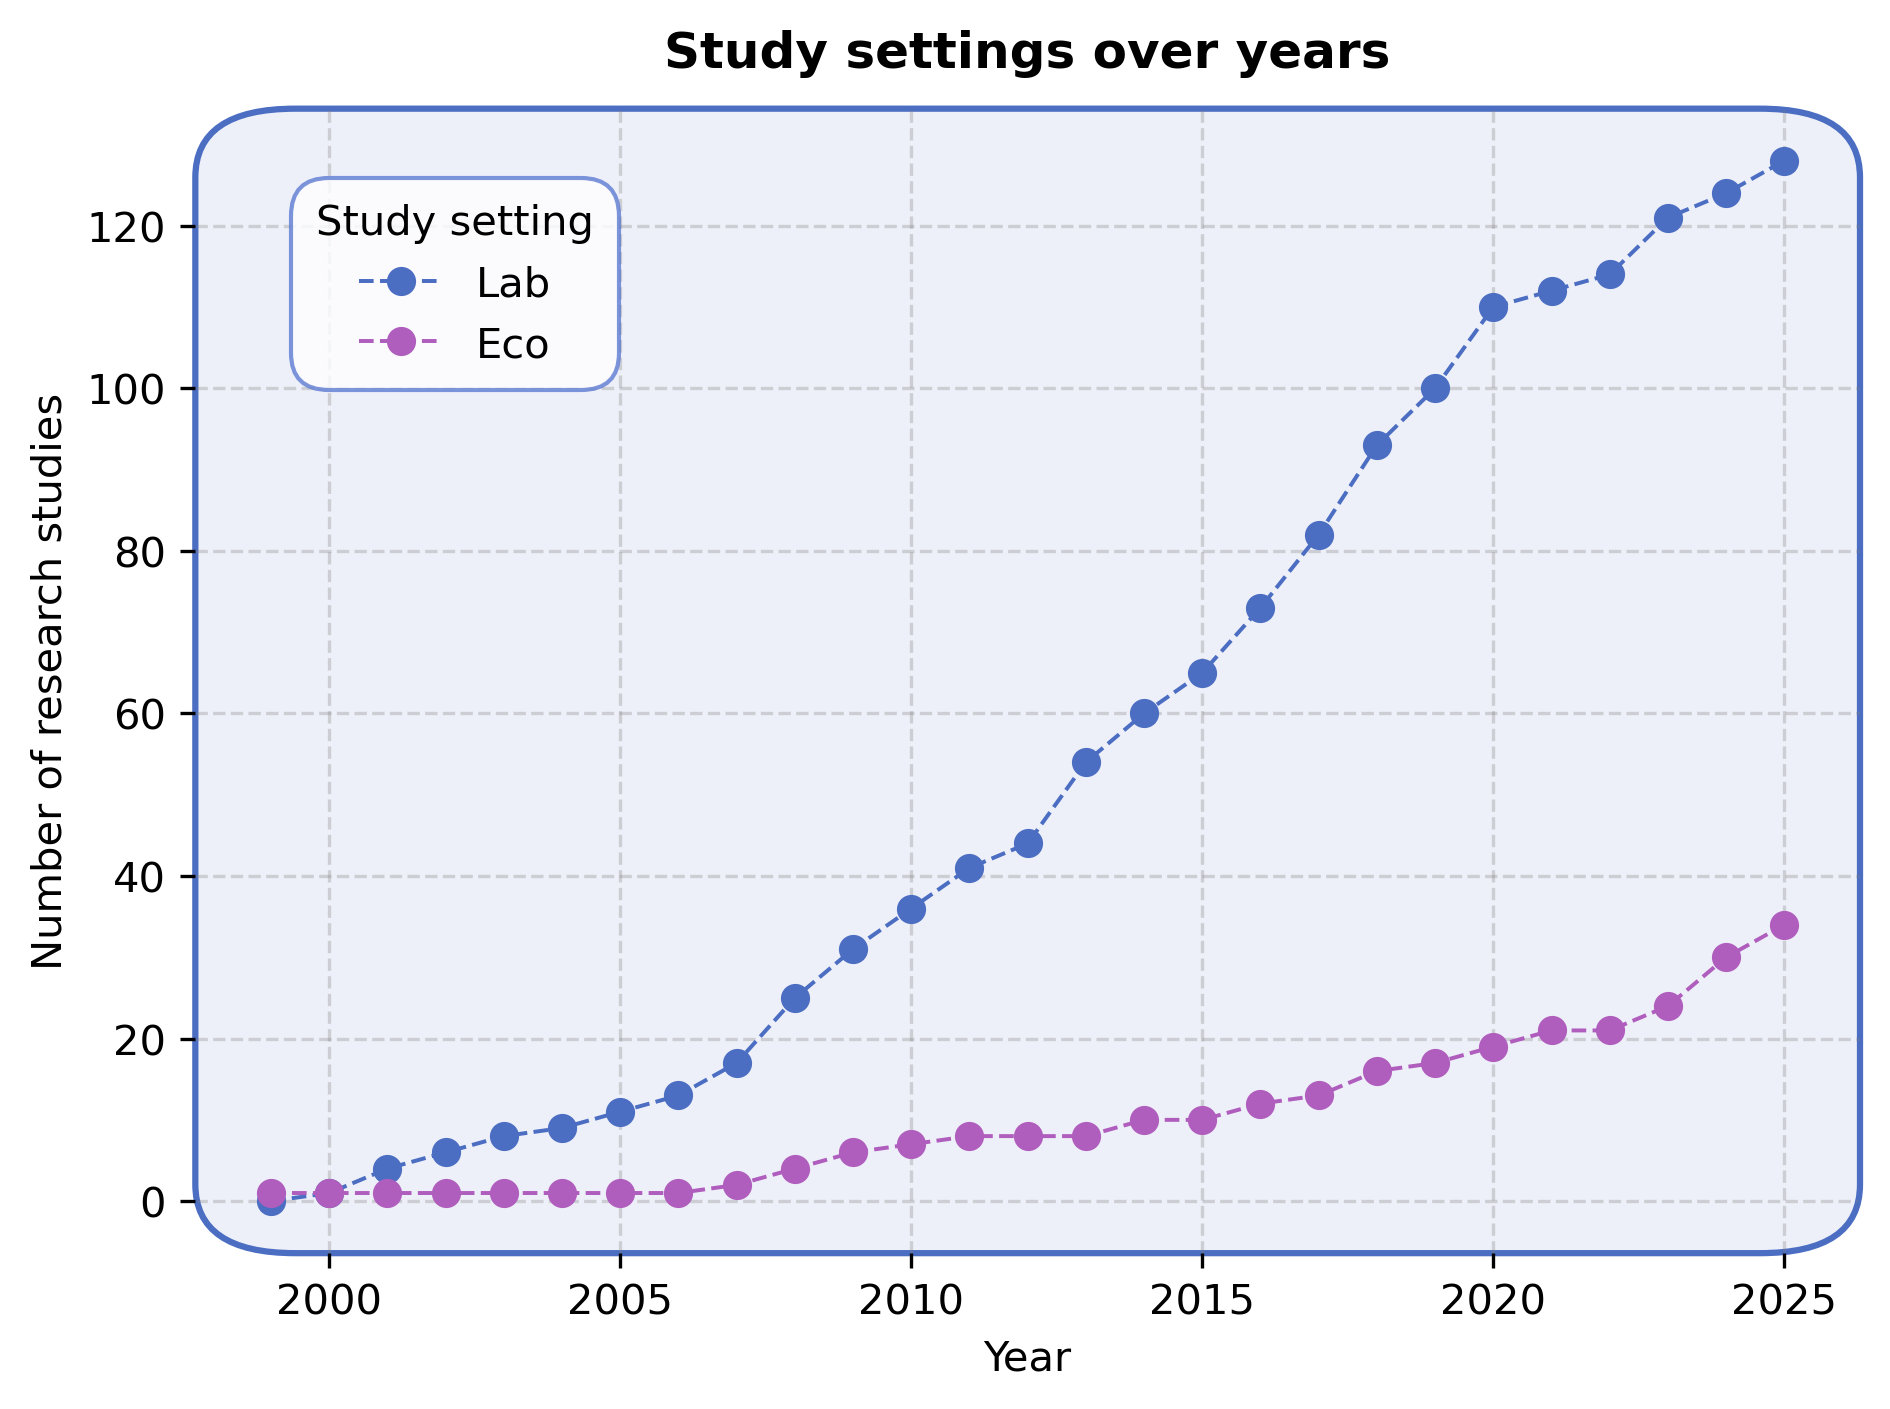

In [76]:
import numpy as np

# Create the plot
fig, ax = plt.subplots(dpi=300,subplot_kw={'projection': 'fancy_box_axes'})
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)
ax.set_facecolor('#EEF0F9')
ax.grid(
            True,             # enable grid
            color='gray',     # light gray grid lines
            alpha=0.3,        # transparency
            linestyle='--',   # dashed style looks nicer in papers
            linewidth=0.8     # slightly thin
        )

data = study_setting['lab']
# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

ax.plot(years,np.cumsum(counts),'o',linestyle='--',color='#4B6DC2',linewidth=.95,label='Lab')

data = study_setting['eco']
# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

ax.plot(years,np.cumsum(counts),'o',linestyle='--',color='#B05EBE',linewidth=.95,label='Eco')

# Draw figure so that legend is placed
fig.canvas.draw()
       
# Add rounded corners to legend
legend = ax.legend(
            title='Study setting',
            frameon=True,
            fancybox=True,  # Enables rounded corners
            edgecolor="#5C7BD1",
            bbox_to_anchor=(.05, 0.95),
            loc="upper left" 
    )
legend.get_frame().set_boxstyle("round,pad=0.2, rounding_size=0.9")  # Adjust rounding
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Number of research studies', fontsize=10)
ax.set_title('Study settings over years', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('Study settings.png',format='png')

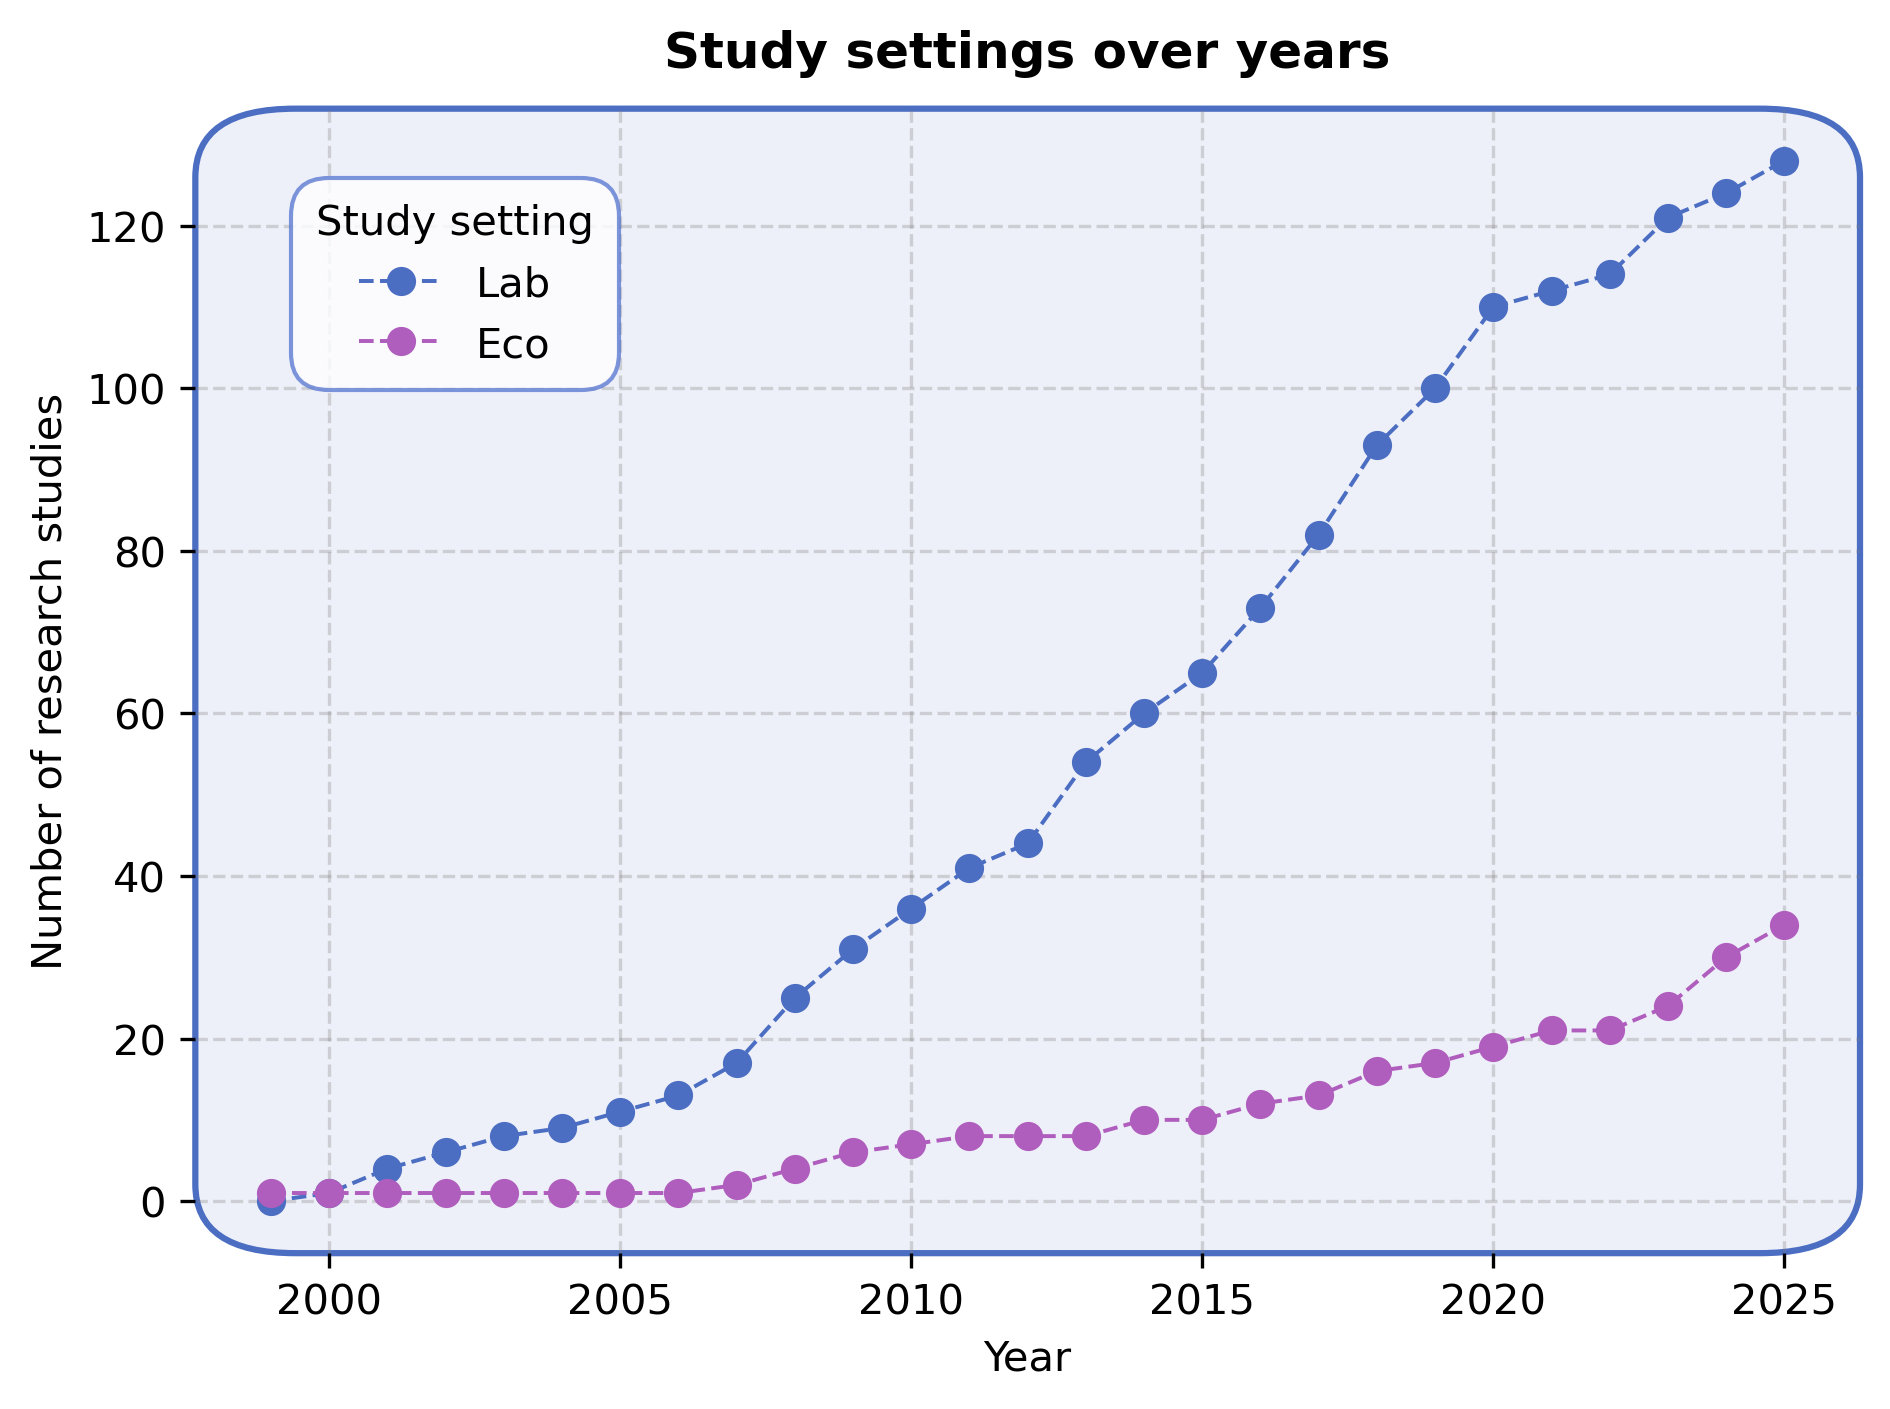

In [131]:
import numpy as np

# Create the plot
fig, ax = plt.subplots(dpi=300,subplot_kw={'projection': 'fancy_box_axes'})
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)
ax.set_facecolor('#EEF0F9')
ax.grid(
            True,             # enable grid
            color='gray',     # light gray grid lines
            alpha=0.3,        # transparency
            linestyle='--',   # dashed style looks nicer in papers
            linewidth=0.8     # slightly thin
        )

data = study_setting['lab']
# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

ax.plot(years,np.cumsum(counts),'o',linestyle='--',color='#4B6DC2',linewidth=.95,label='Lab')

data = study_setting['eco']
# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

ax.plot(years,np.cumsum(counts),'o',linestyle='--',color='#B05EBE',linewidth=.95,label='Eco')

# Draw figure so that legend is placed
fig.canvas.draw()
       
# Add rounded corners to legend
legend = ax.legend(
            title='Study setting',
            frameon=True,
            fancybox=True,  # Enables rounded corners
            edgecolor="#5C7BD1",
            bbox_to_anchor=(.05, 0.95),
            loc="upper left" 
    )
legend.get_frame().set_boxstyle("round,pad=0.2, rounding_size=0.9")  # Adjust rounding
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Number of research studies', fontsize=10)
ax.set_title('Study settings over years', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('Study settings.png',format='png')

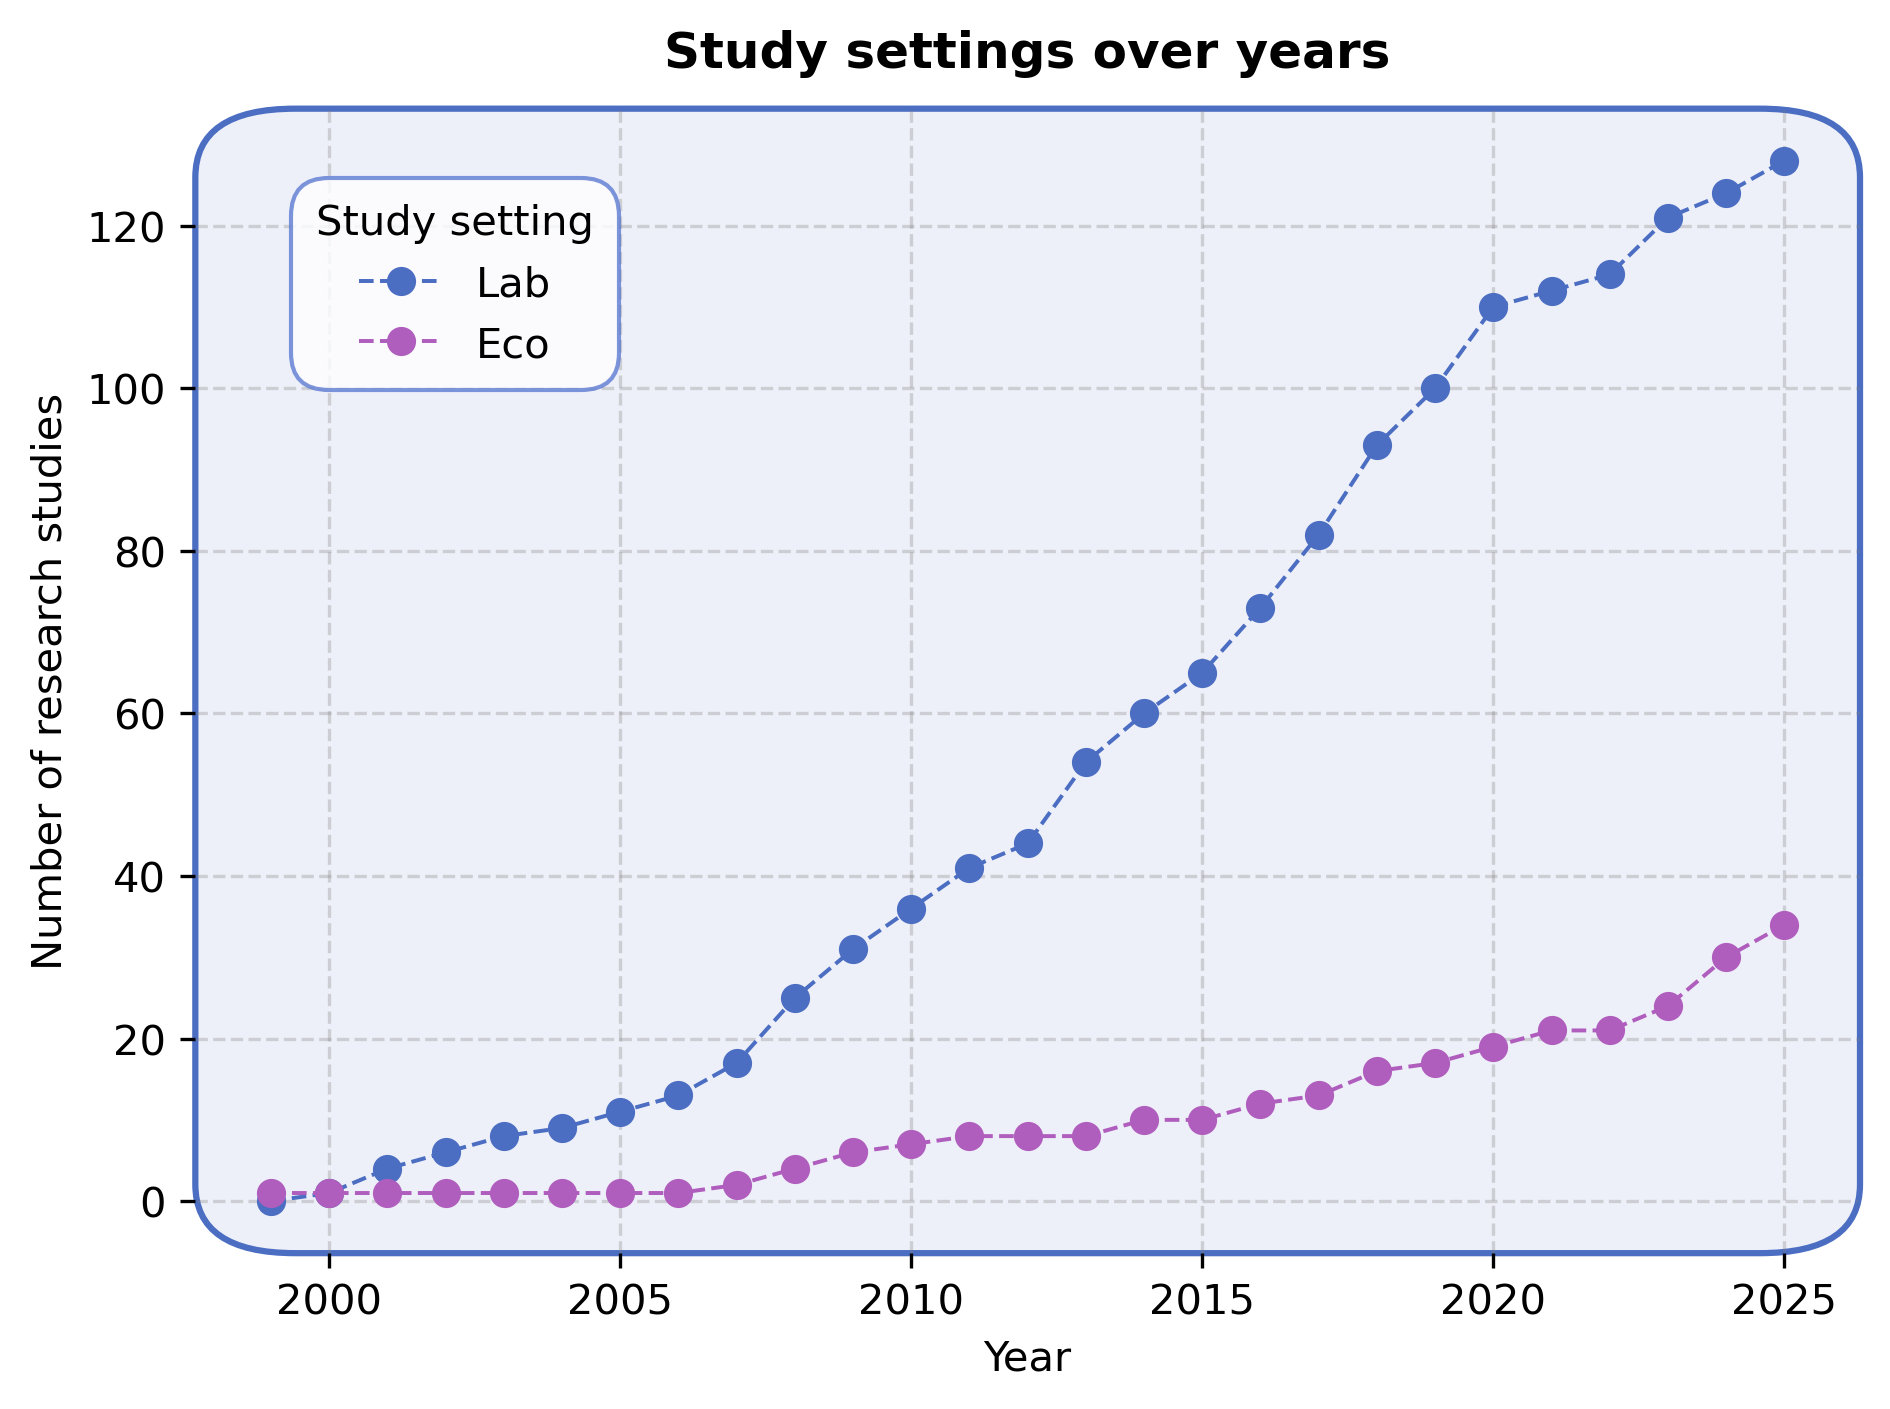

In [78]:
import numpy as np

# Create the plot
fig, ax = plt.subplots(dpi=300,subplot_kw={'projection': 'fancy_box_axes'})
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)
ax.set_facecolor('#EEF0F9')
ax.grid(
            True,             # enable grid
            color='gray',     # light gray grid lines
            alpha=0.3,        # transparency
            linestyle='--',   # dashed style looks nicer in papers
            linewidth=0.8     # slightly thin
        )

data = study_setting['lab']
# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

ax.plot(years,np.cumsum(counts),'o',linestyle='--',color='#4B6DC2',linewidth=.95,label='Lab')

data = study_setting['eco']
# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

ax.plot(years,np.cumsum(counts),'o',linestyle='--',color='#B05EBE',linewidth=.95,label='Eco')

# Draw figure so that legend is placed
fig.canvas.draw()
       
# Add rounded corners to legend
legend = ax.legend(
            title='Study setting',
            frameon=True,
            fancybox=True,  # Enables rounded corners
            edgecolor="#5C7BD1",
            bbox_to_anchor=(.05, 0.95),
            loc="upper left" 
    )
legend.get_frame().set_boxstyle("round,pad=0.2, rounding_size=0.9")  # Adjust rounding
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Number of research studies', fontsize=10)
ax.set_title('Study settings over years', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('Study settings.png',format='png')

### Sample size 

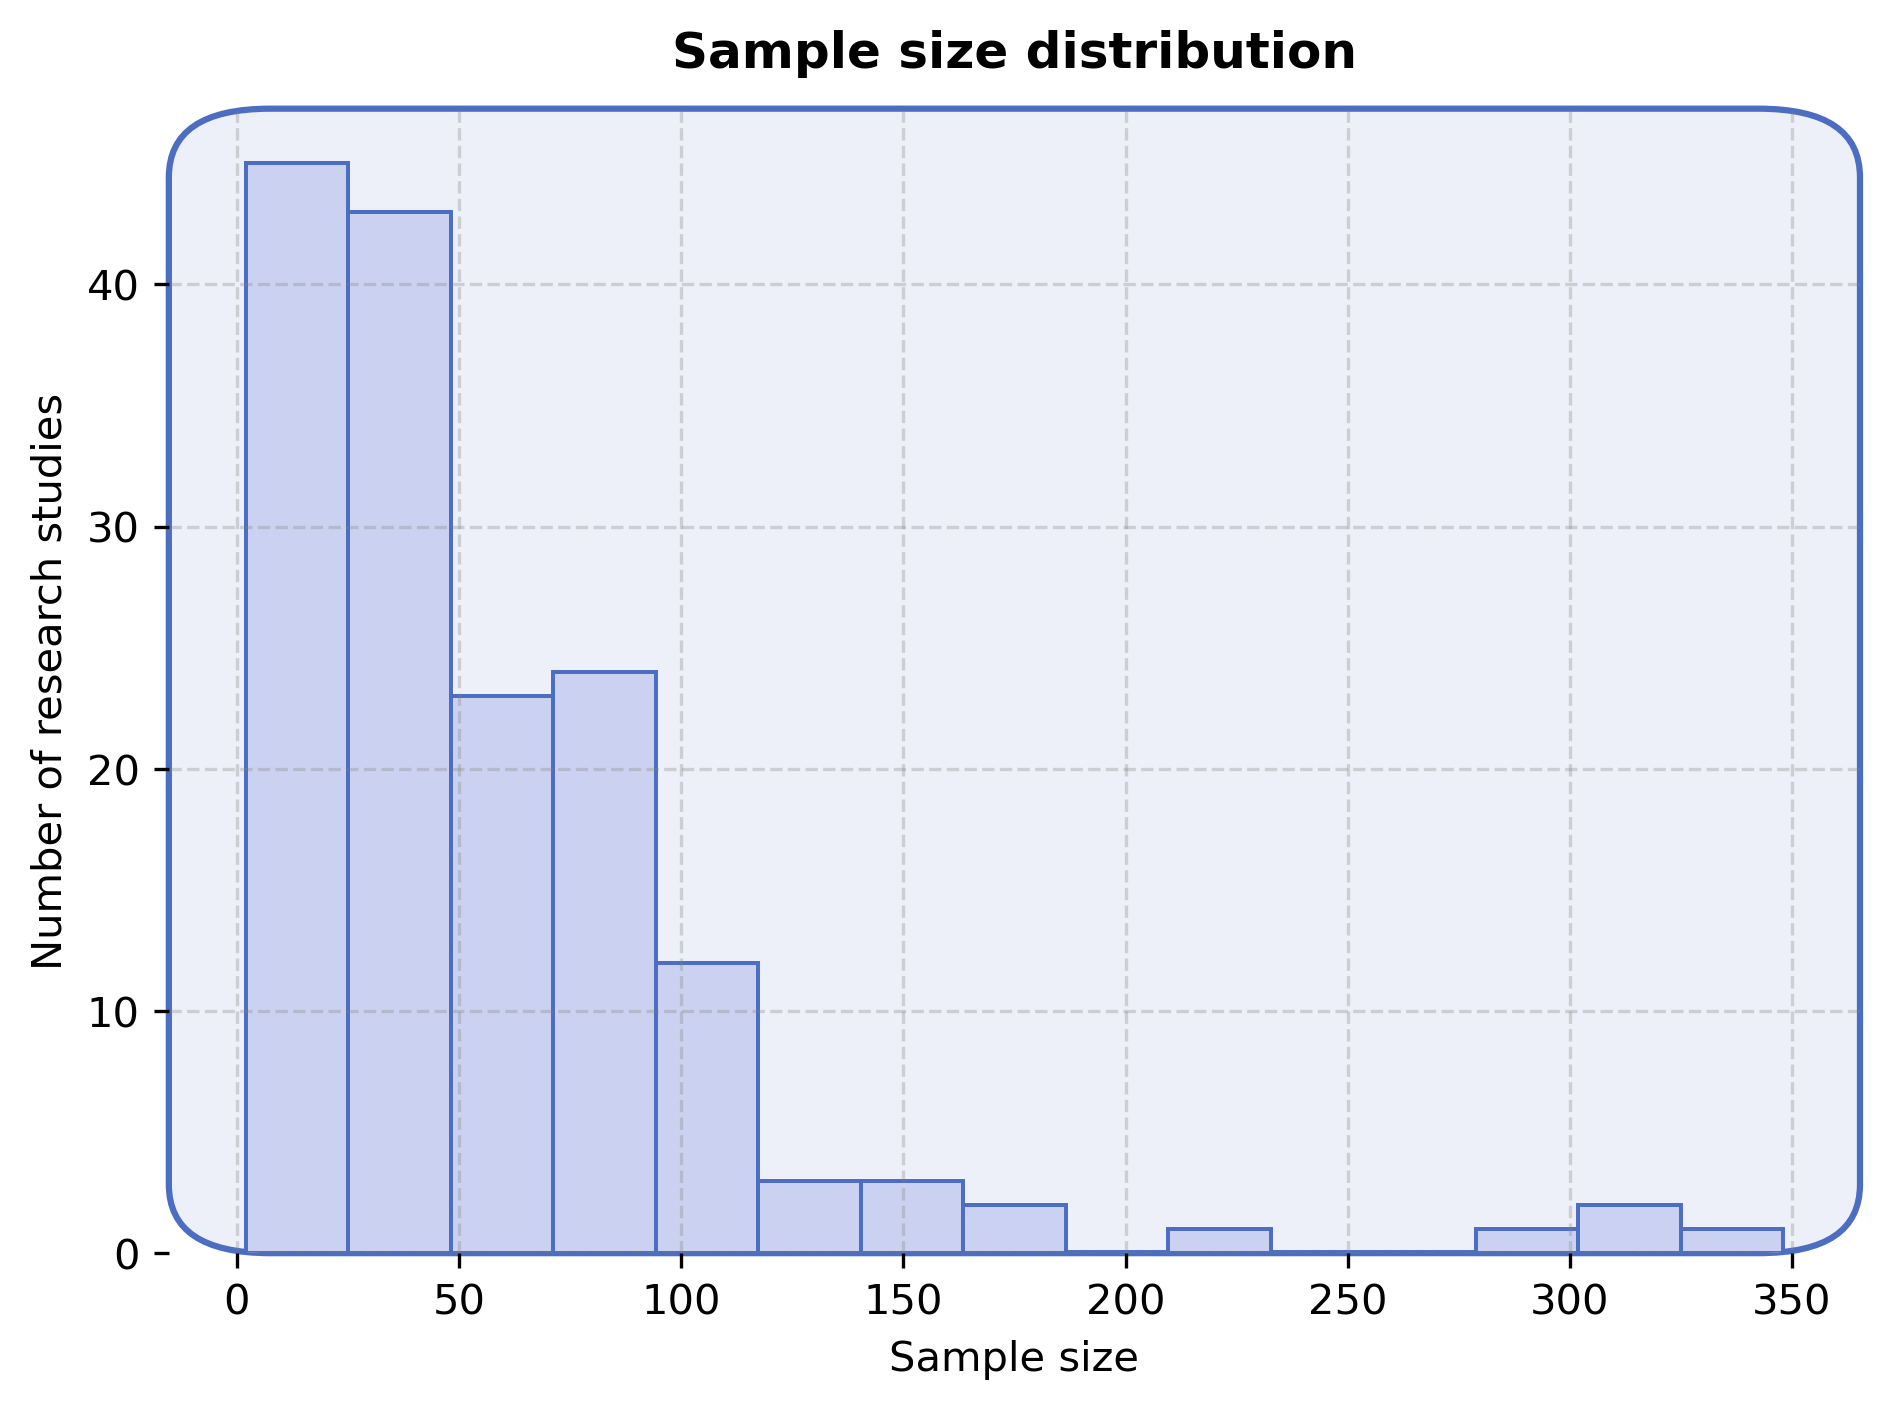

In [80]:

# Create the plot
fig, ax = plt.subplots(dpi=300,subplot_kw={'projection': 'fancy_box_axes'})
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)
ax.set_facecolor('#EEF0F9')
ax.grid(
            True,             # enable grid
            color='gray',     # light gray grid lines
            alpha=0.3,        # transparency
            linestyle='--',   # dashed style looks nicer in papers
            linewidth=0.8     # slightly thin
        )


# Plot histogram
n, bins, patches = ax.hist(
    sample_size,
    bins=15,
    edgecolor='#4B6DC2',
    linewidth=0.95,
    histtype='bar',
    label='Eco',
    color='#CBD2F1'  # lighter face color
)

# Optional: Create spacing between bars
for patch in patches:
    patch.set_linestyle('-')
    patch.set_linewidth(0.95)
    patch.set_edgecolor('#4B6DC2')
    patch.set_facecolor('#CBD2F1')  # lighter than #4B6DC2



ax.set_xlabel('Sample size', fontsize=10)
ax.set_ylabel('Number of research studies', fontsize=10)
ax.set_title('Sample size distribution', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('Sample size.png',format='png')

### Citations


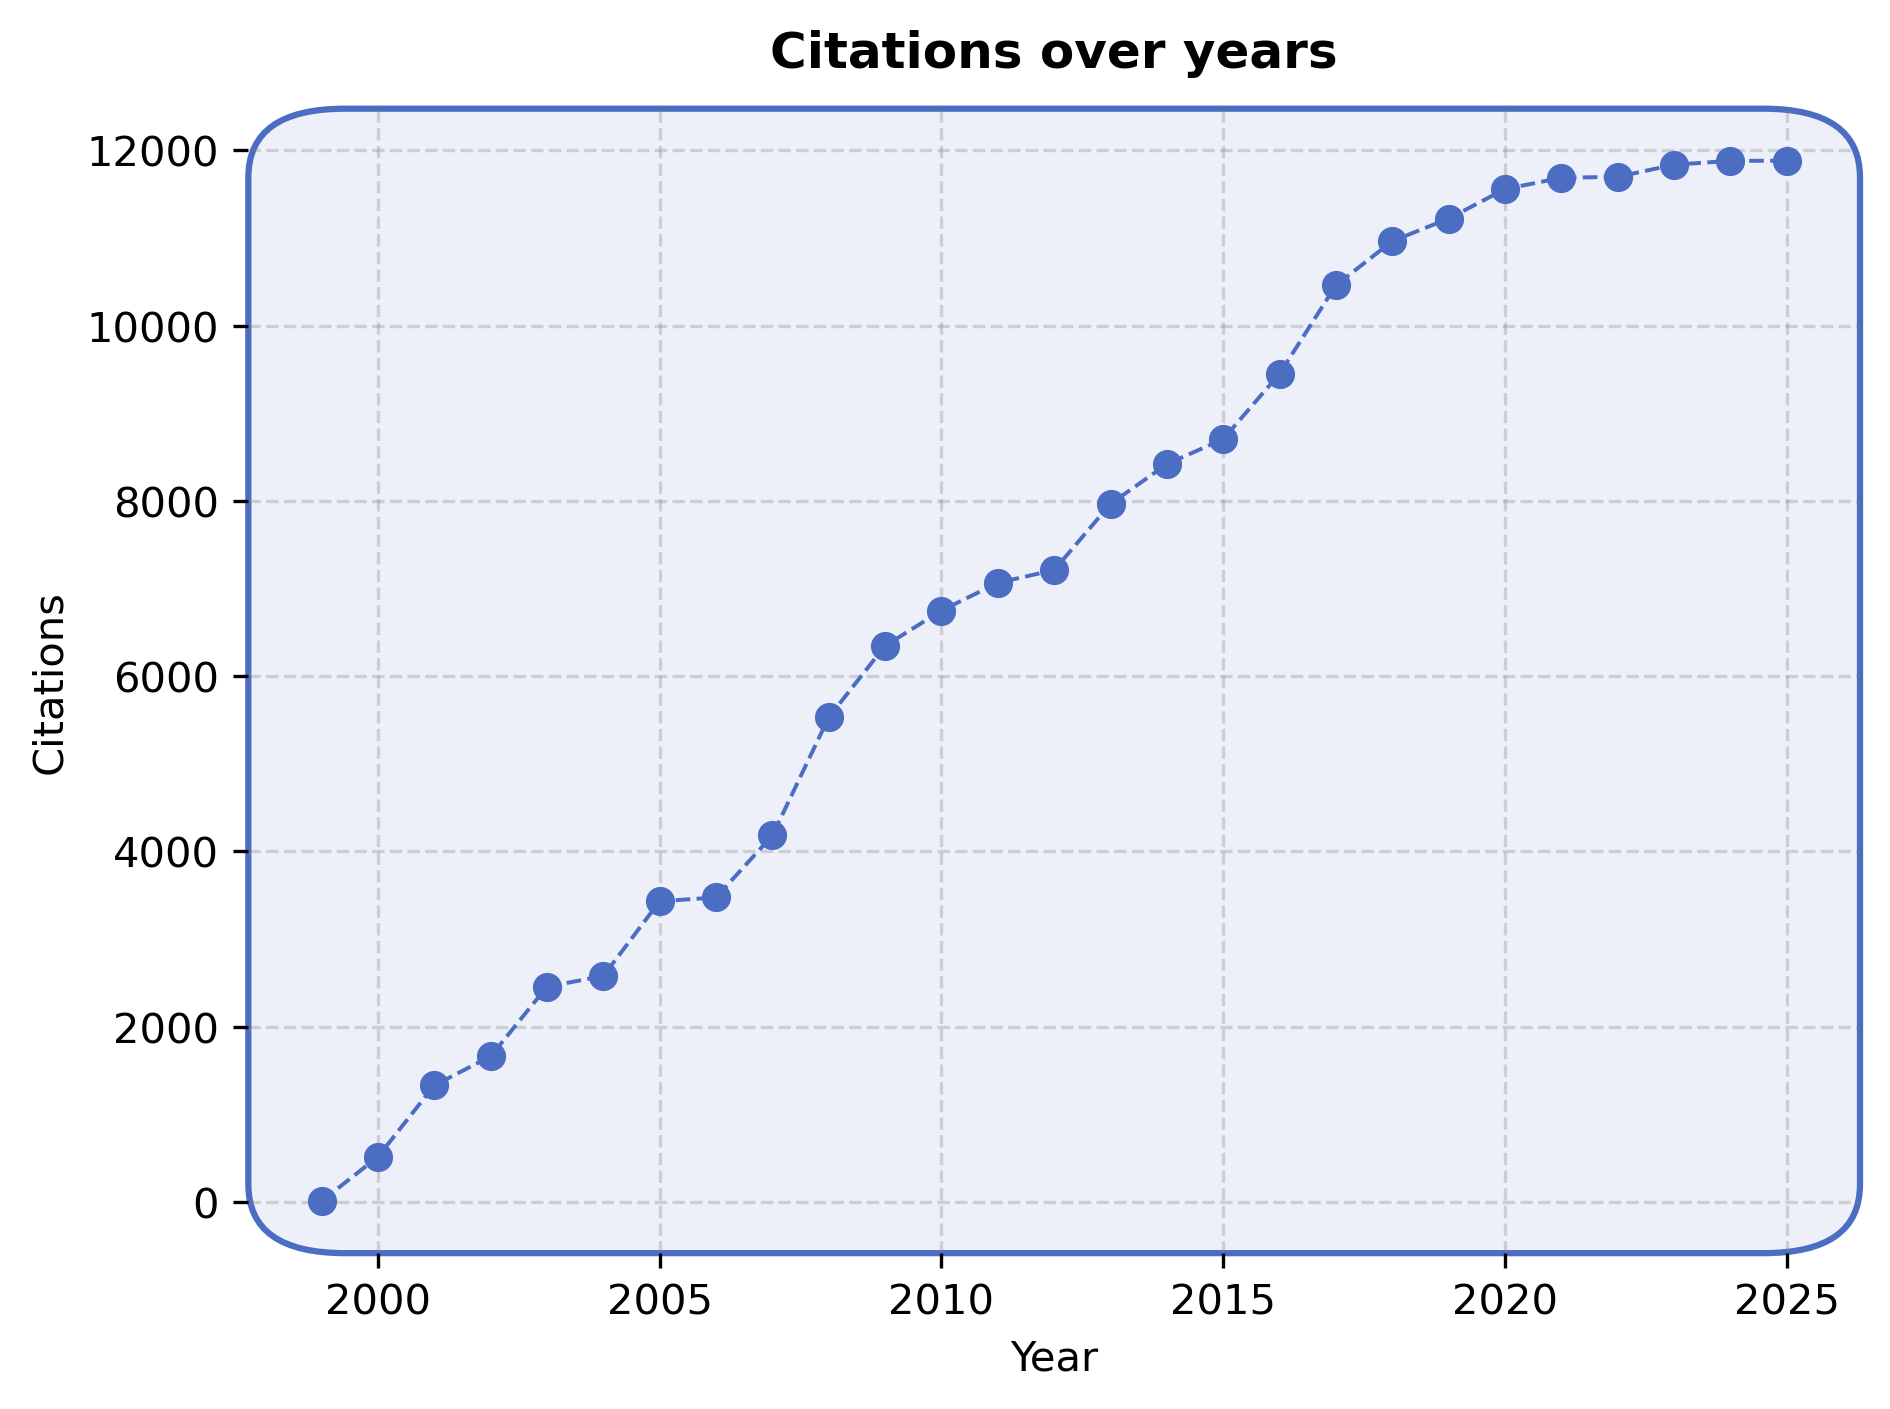

In [82]:
import numpy as np
# Create the plot
fig, ax = plt.subplots(dpi=300,subplot_kw={'projection': 'fancy_box_axes'})
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)
ax.set_facecolor('#EEF0F9')
ax.grid(
            True,             # enable grid
            color='gray',     # light gray grid lines
            alpha=0.3,        # transparency
            linestyle='--',   # dashed style looks nicer in papers
            linewidth=0.8     # slightly thin
        )

data = citations
# Sort data by year
years = sorted(data.keys())
counts = [data[year] for year in years]

ax.plot(years,np.cumsum(counts),'o',linestyle='--',color='#4B6DC2',linewidth=.95)



ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Citations', fontsize=10)
ax.set_title('Citations over years', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('Citations.png',format='png')

In [43]:
import matplotlib.patches as mpatches
import matplotlib.axes as axes
from matplotlib.projections import register_projection


class StaticColorAxisBBox(mpatches.FancyBboxPatch):
    def set_edgecolor(self, color):
        if hasattr(self, "_original_edgecolor"):
            return
        self._original_edgecolor = color
        self._set_edgecolor(color)

    def set_linewidth(self, w):
        super().set_linewidth(1.5)


class FancyAxes(axes.Axes):
    name = "fancy_box_axes"
    _edgecolor: str

    def __init__(self, *args, **kwargs):
        self._edgecolor = kwargs.pop("edgecolor", None)
        super().__init__(*args, **kwargs)

    def _gen_axes_patch(self):
        return StaticColorAxisBBox(
            (0, 0),
            1.0,
            1.0,
            boxstyle="round, rounding_size=0.06, pad=0",
            edgecolor='#4B6DC2',
            linewidth=5,
        )

register_projection(FancyAxes)

## Plotting trends

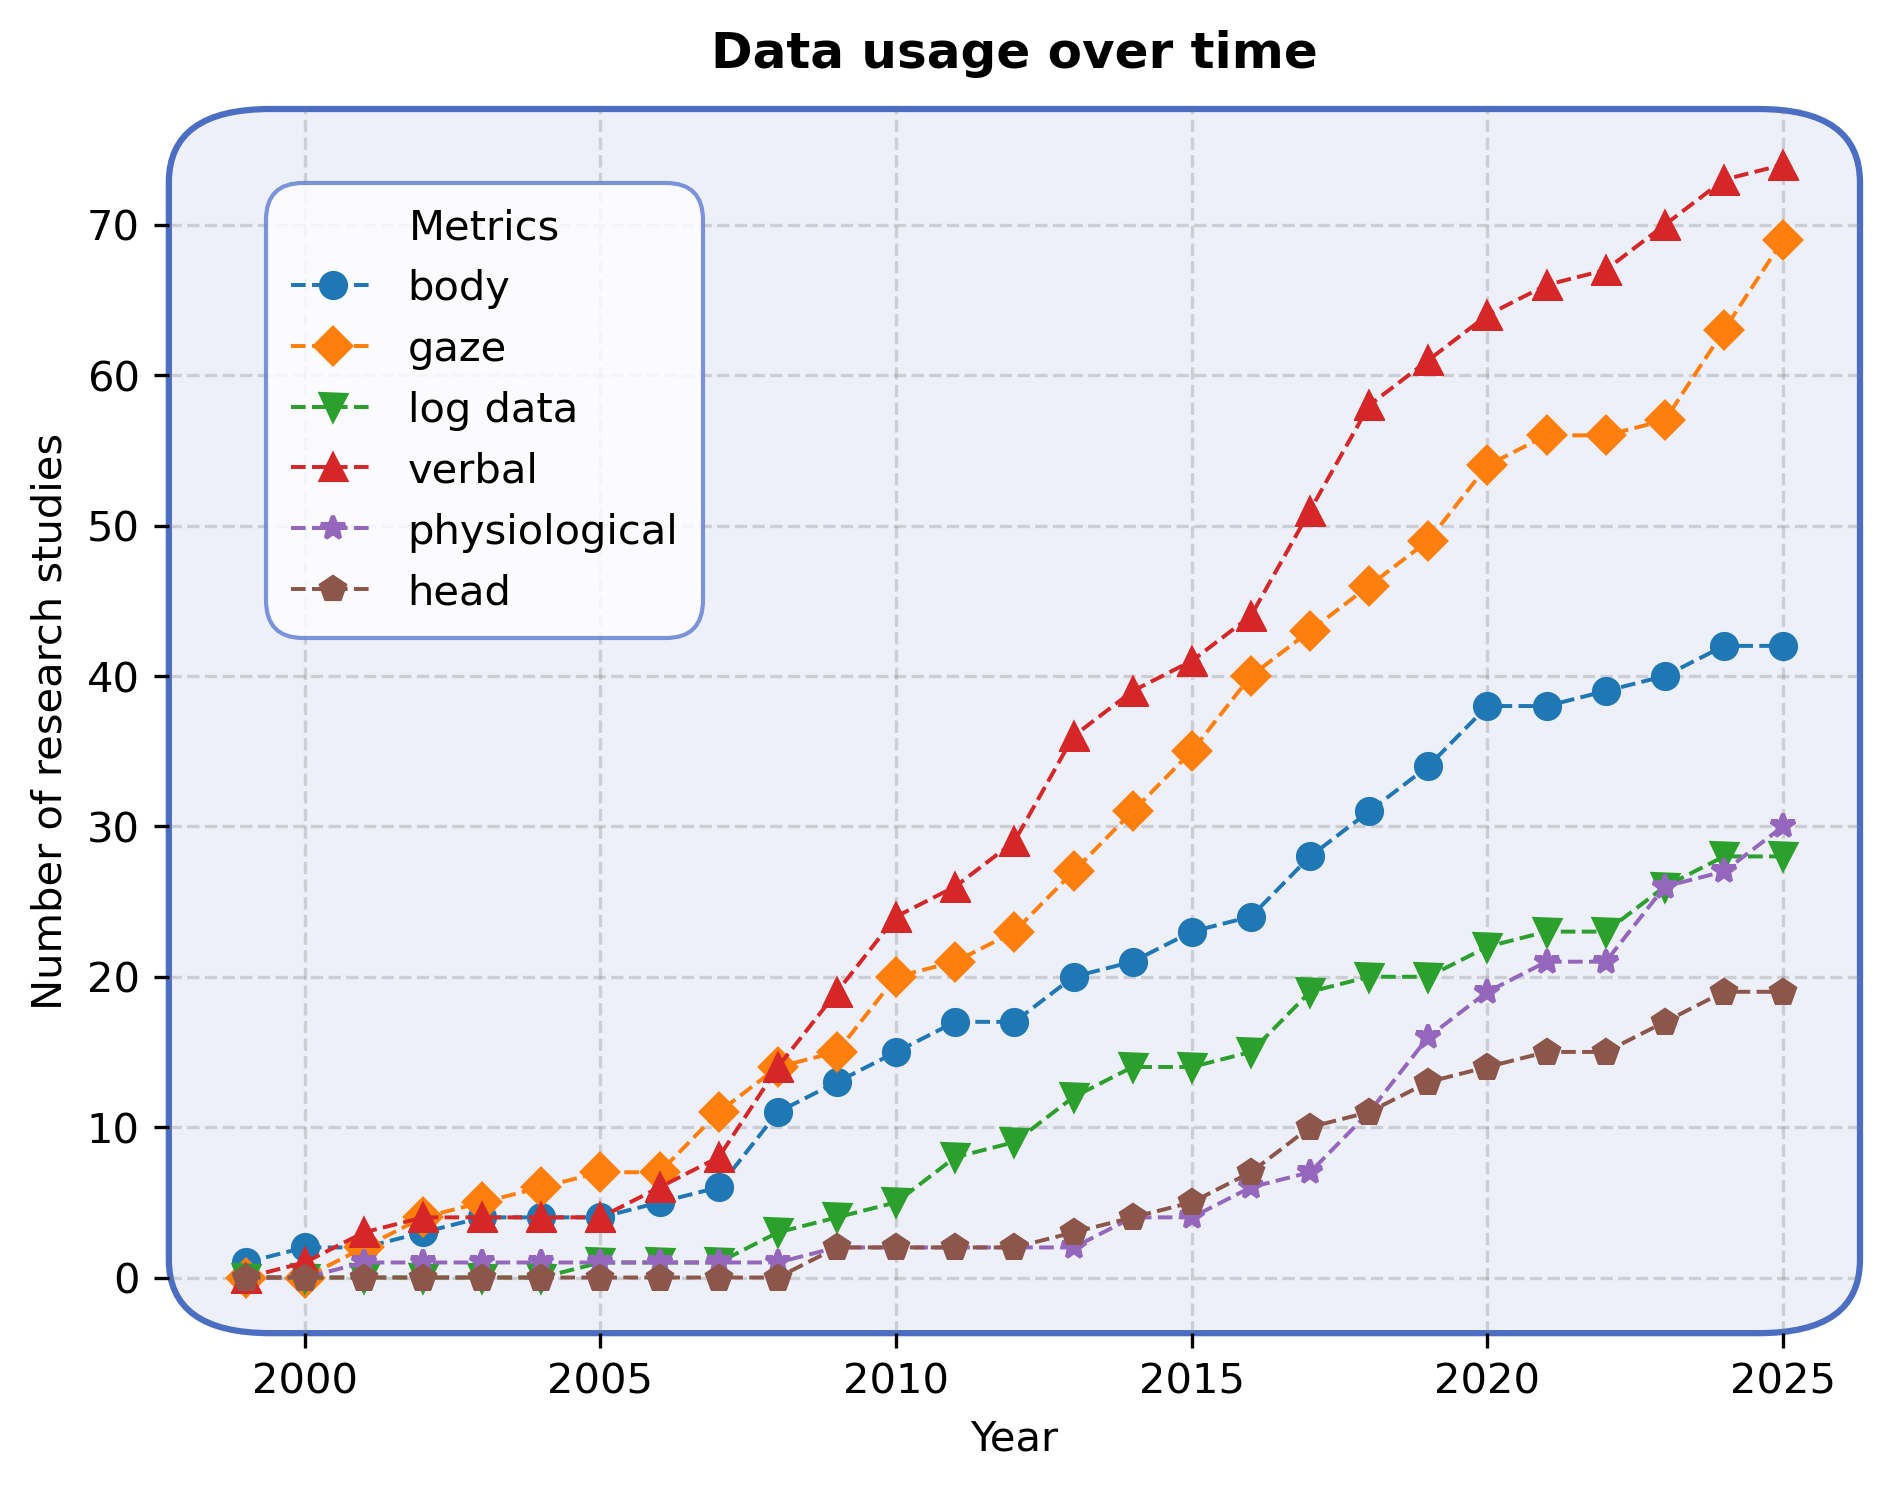

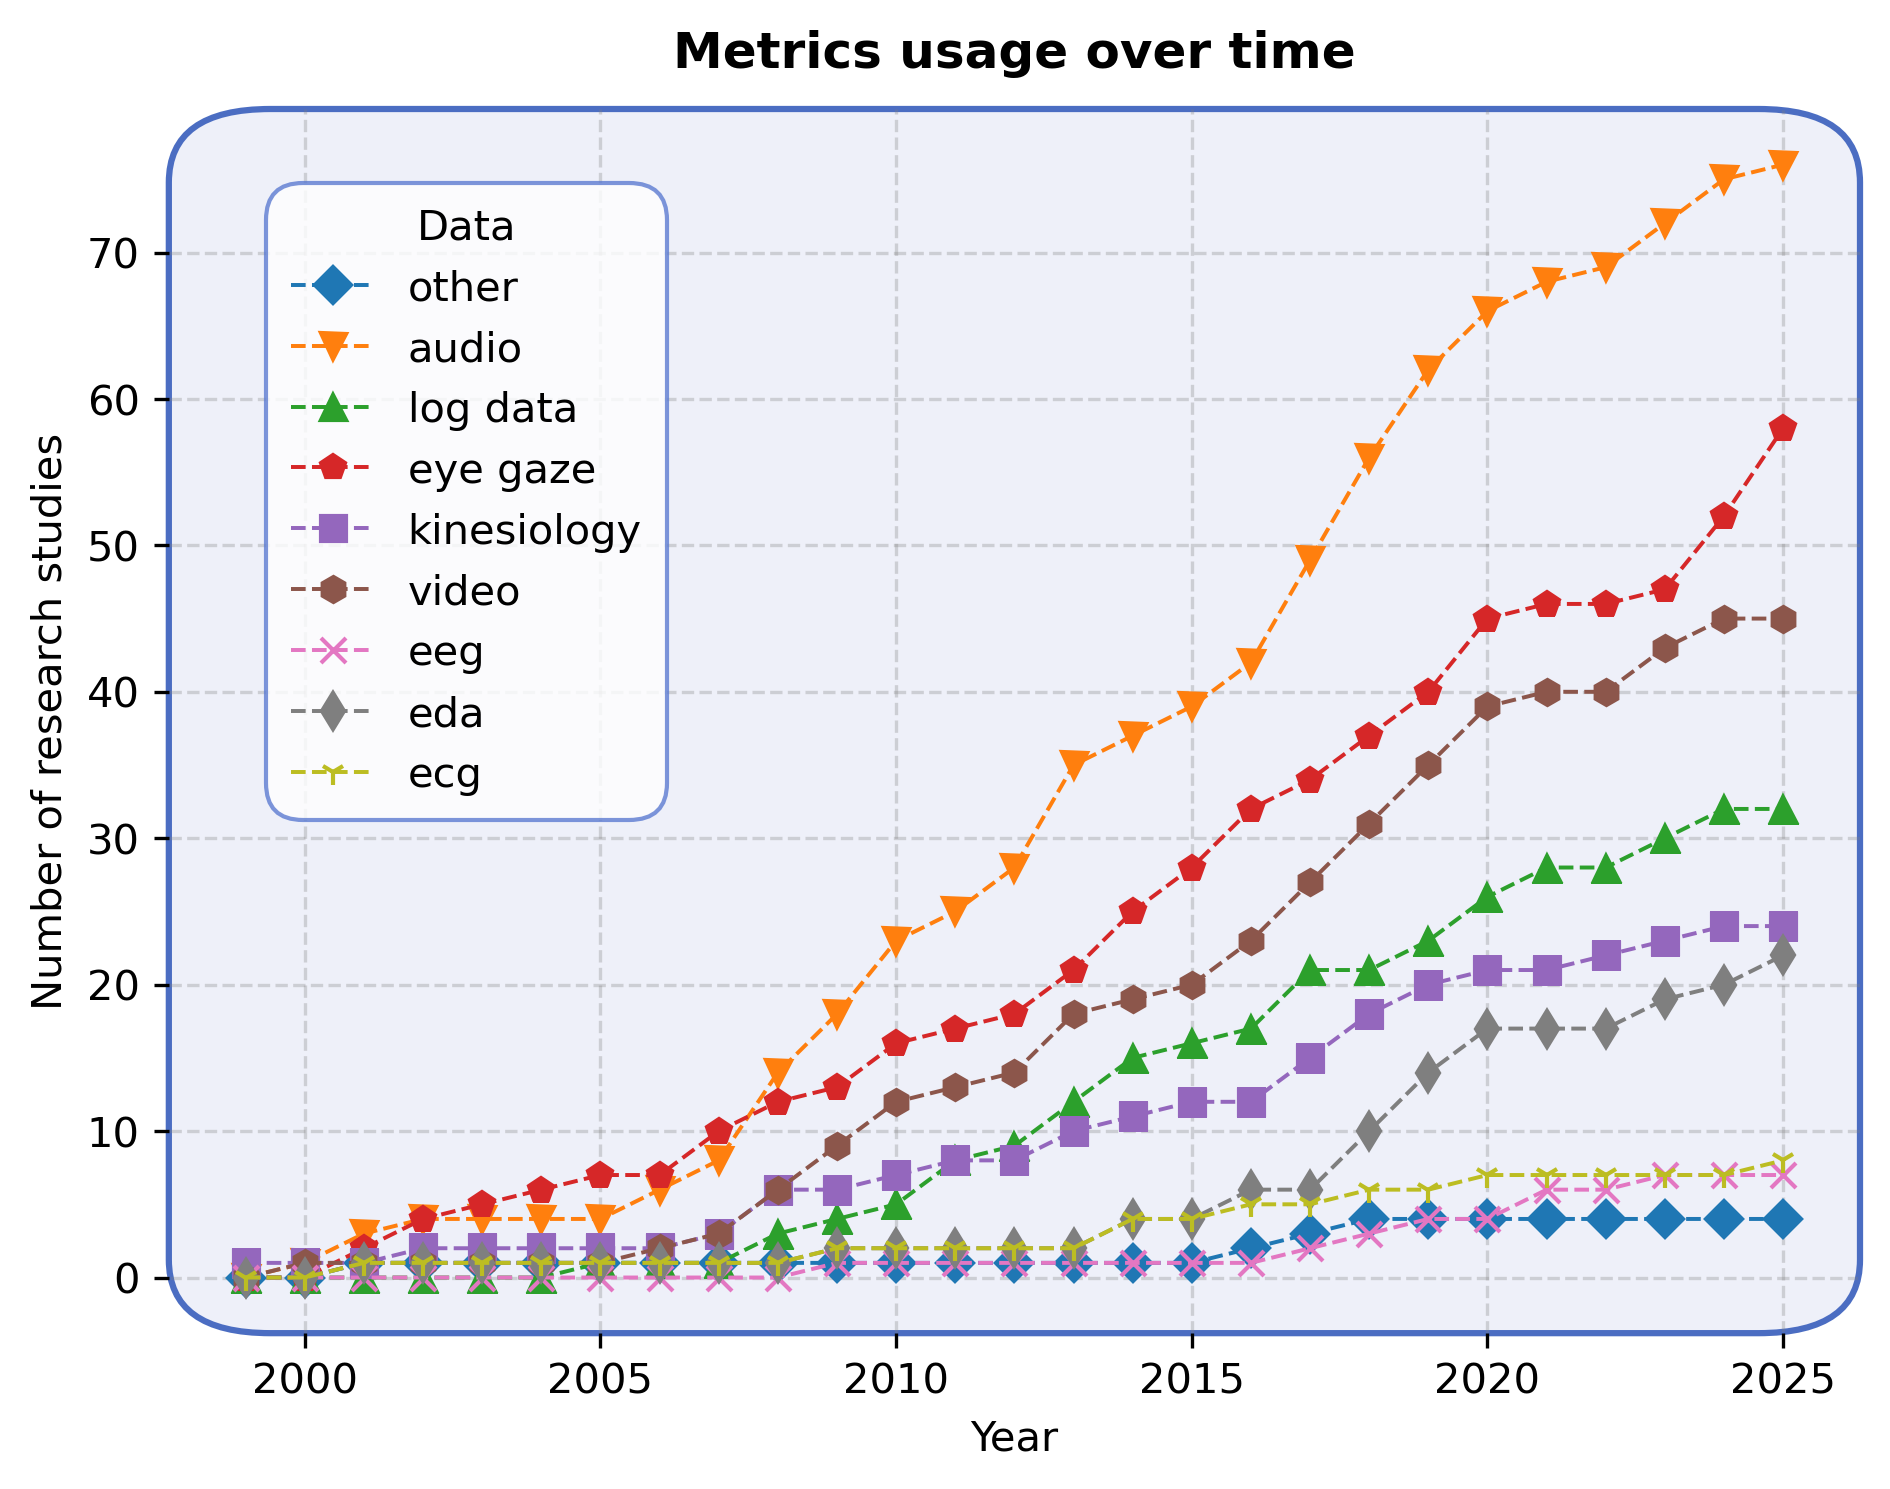

In [84]:
data_ = lit.plot_trends('metrics_lg', fig_title="Data usage over time",attribute_label="Metrics")
data_ = lit.plot_trends('data', skip_values=['fnirs','bvp'], fig_title="Metrics usage over time",attribute_label="Data")

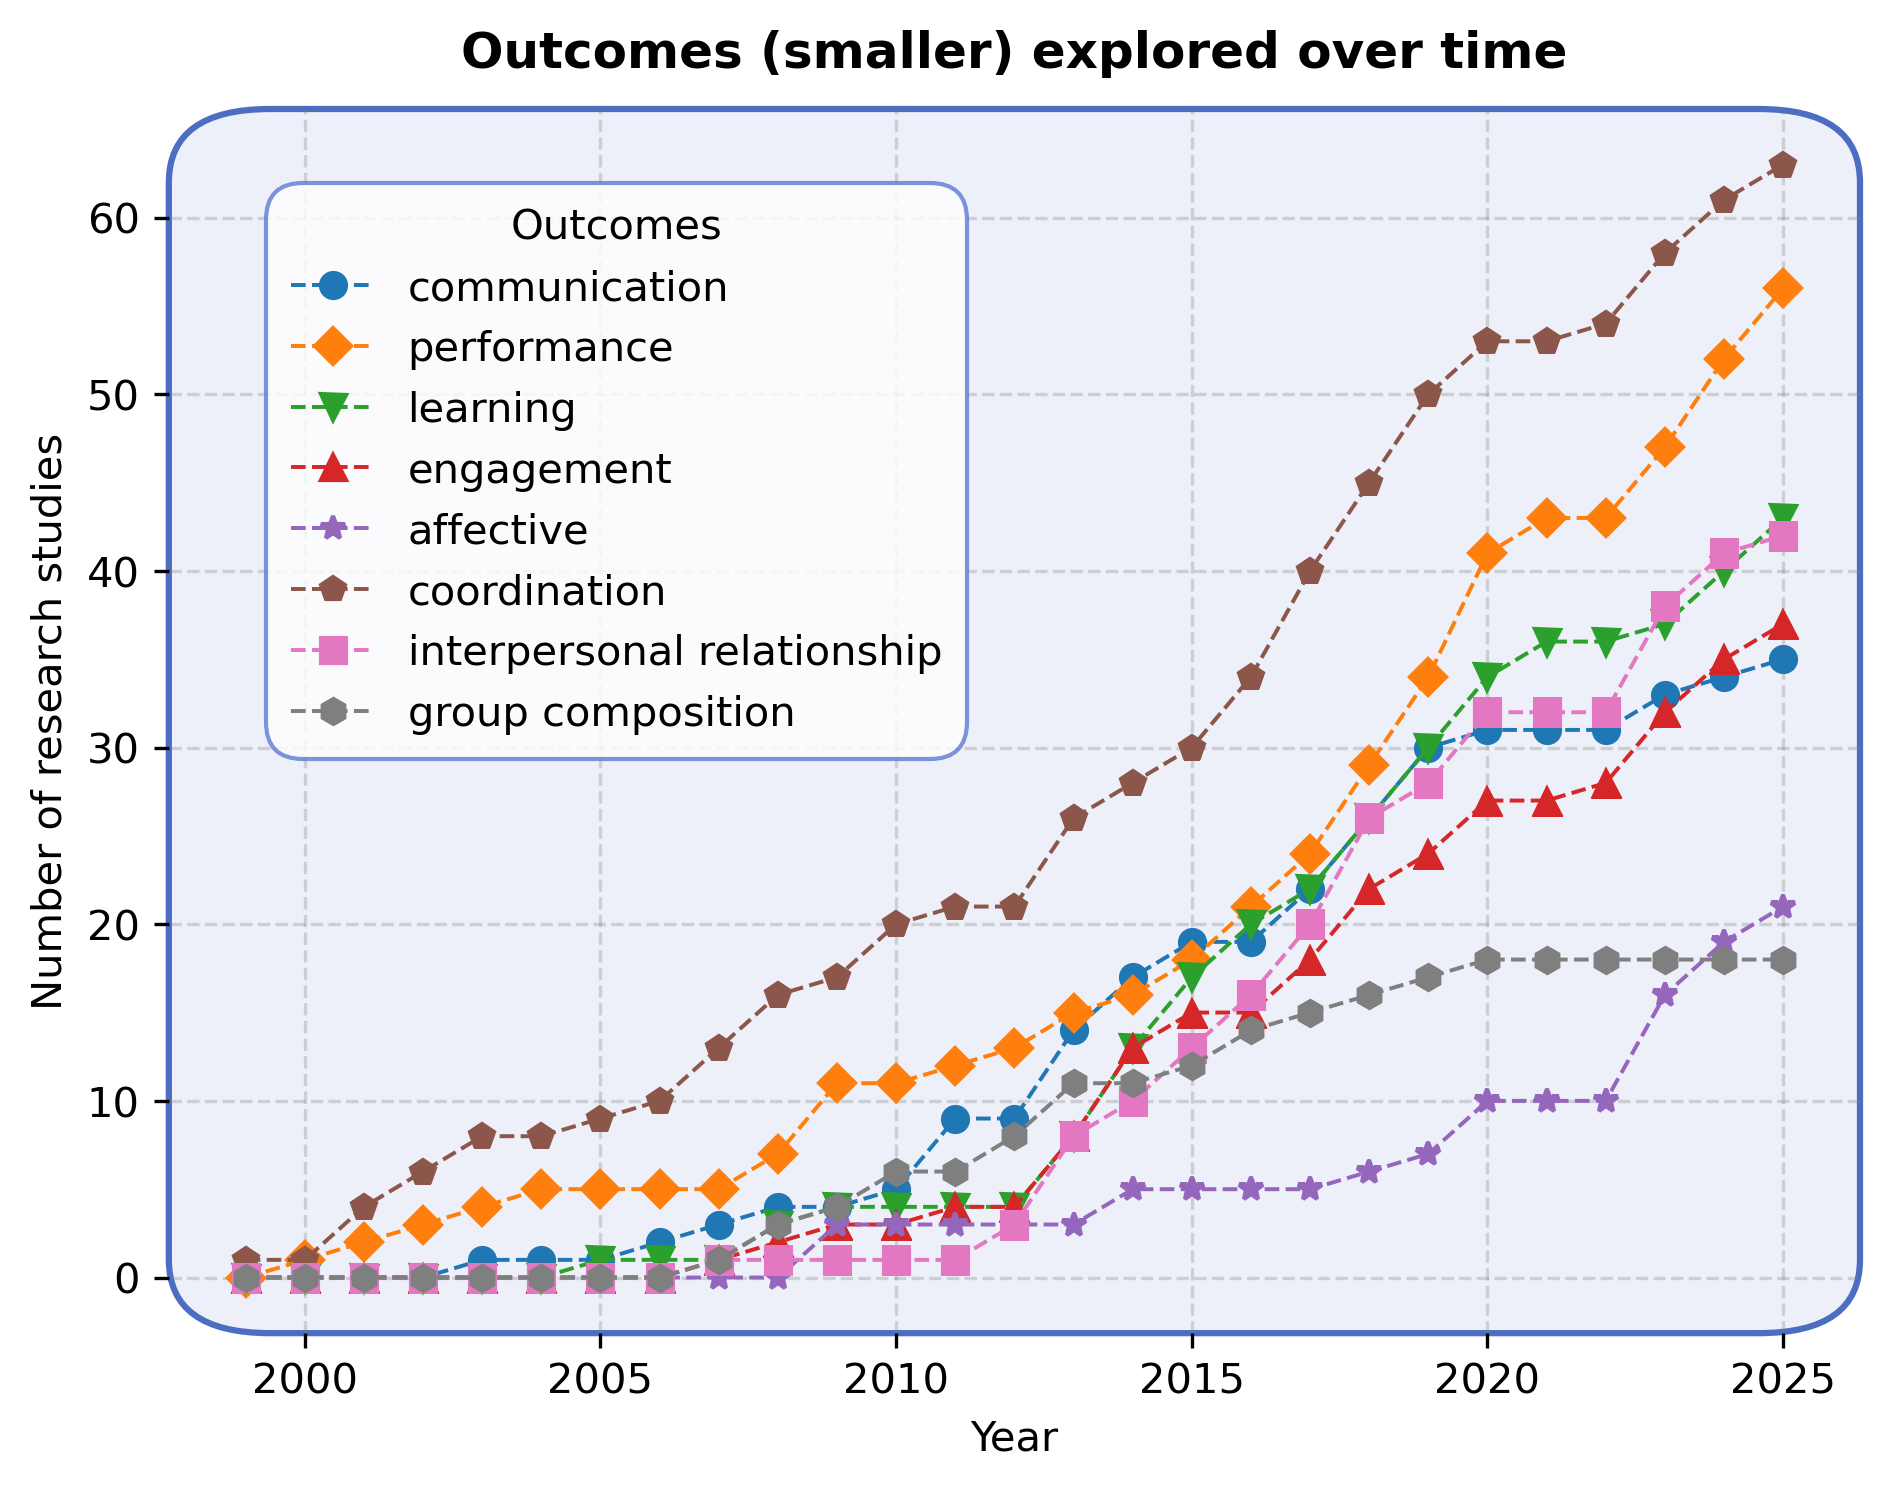

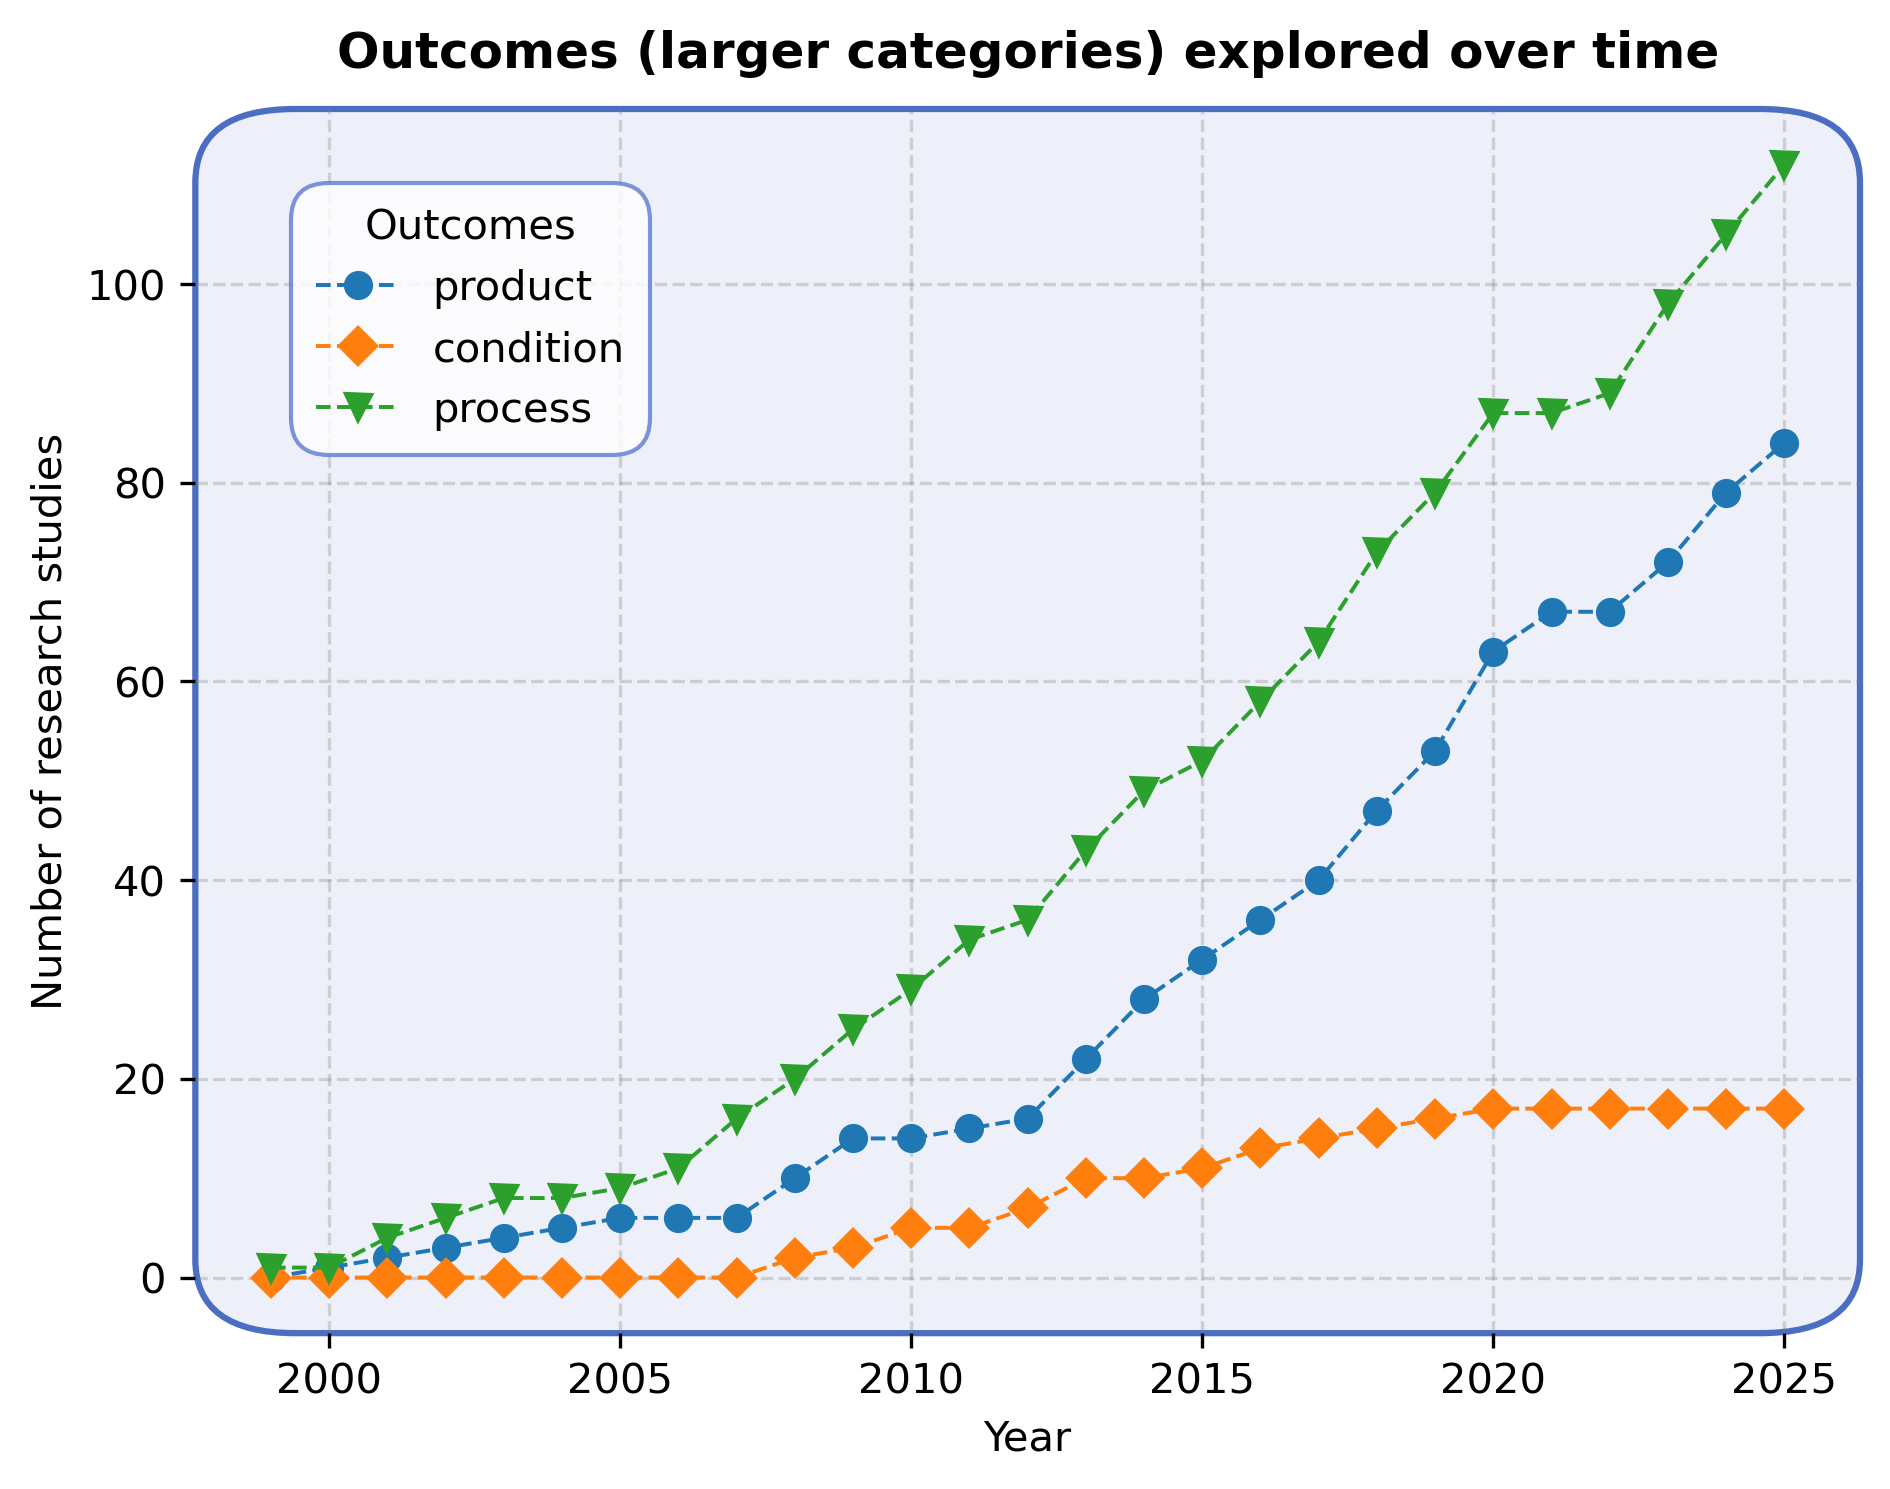

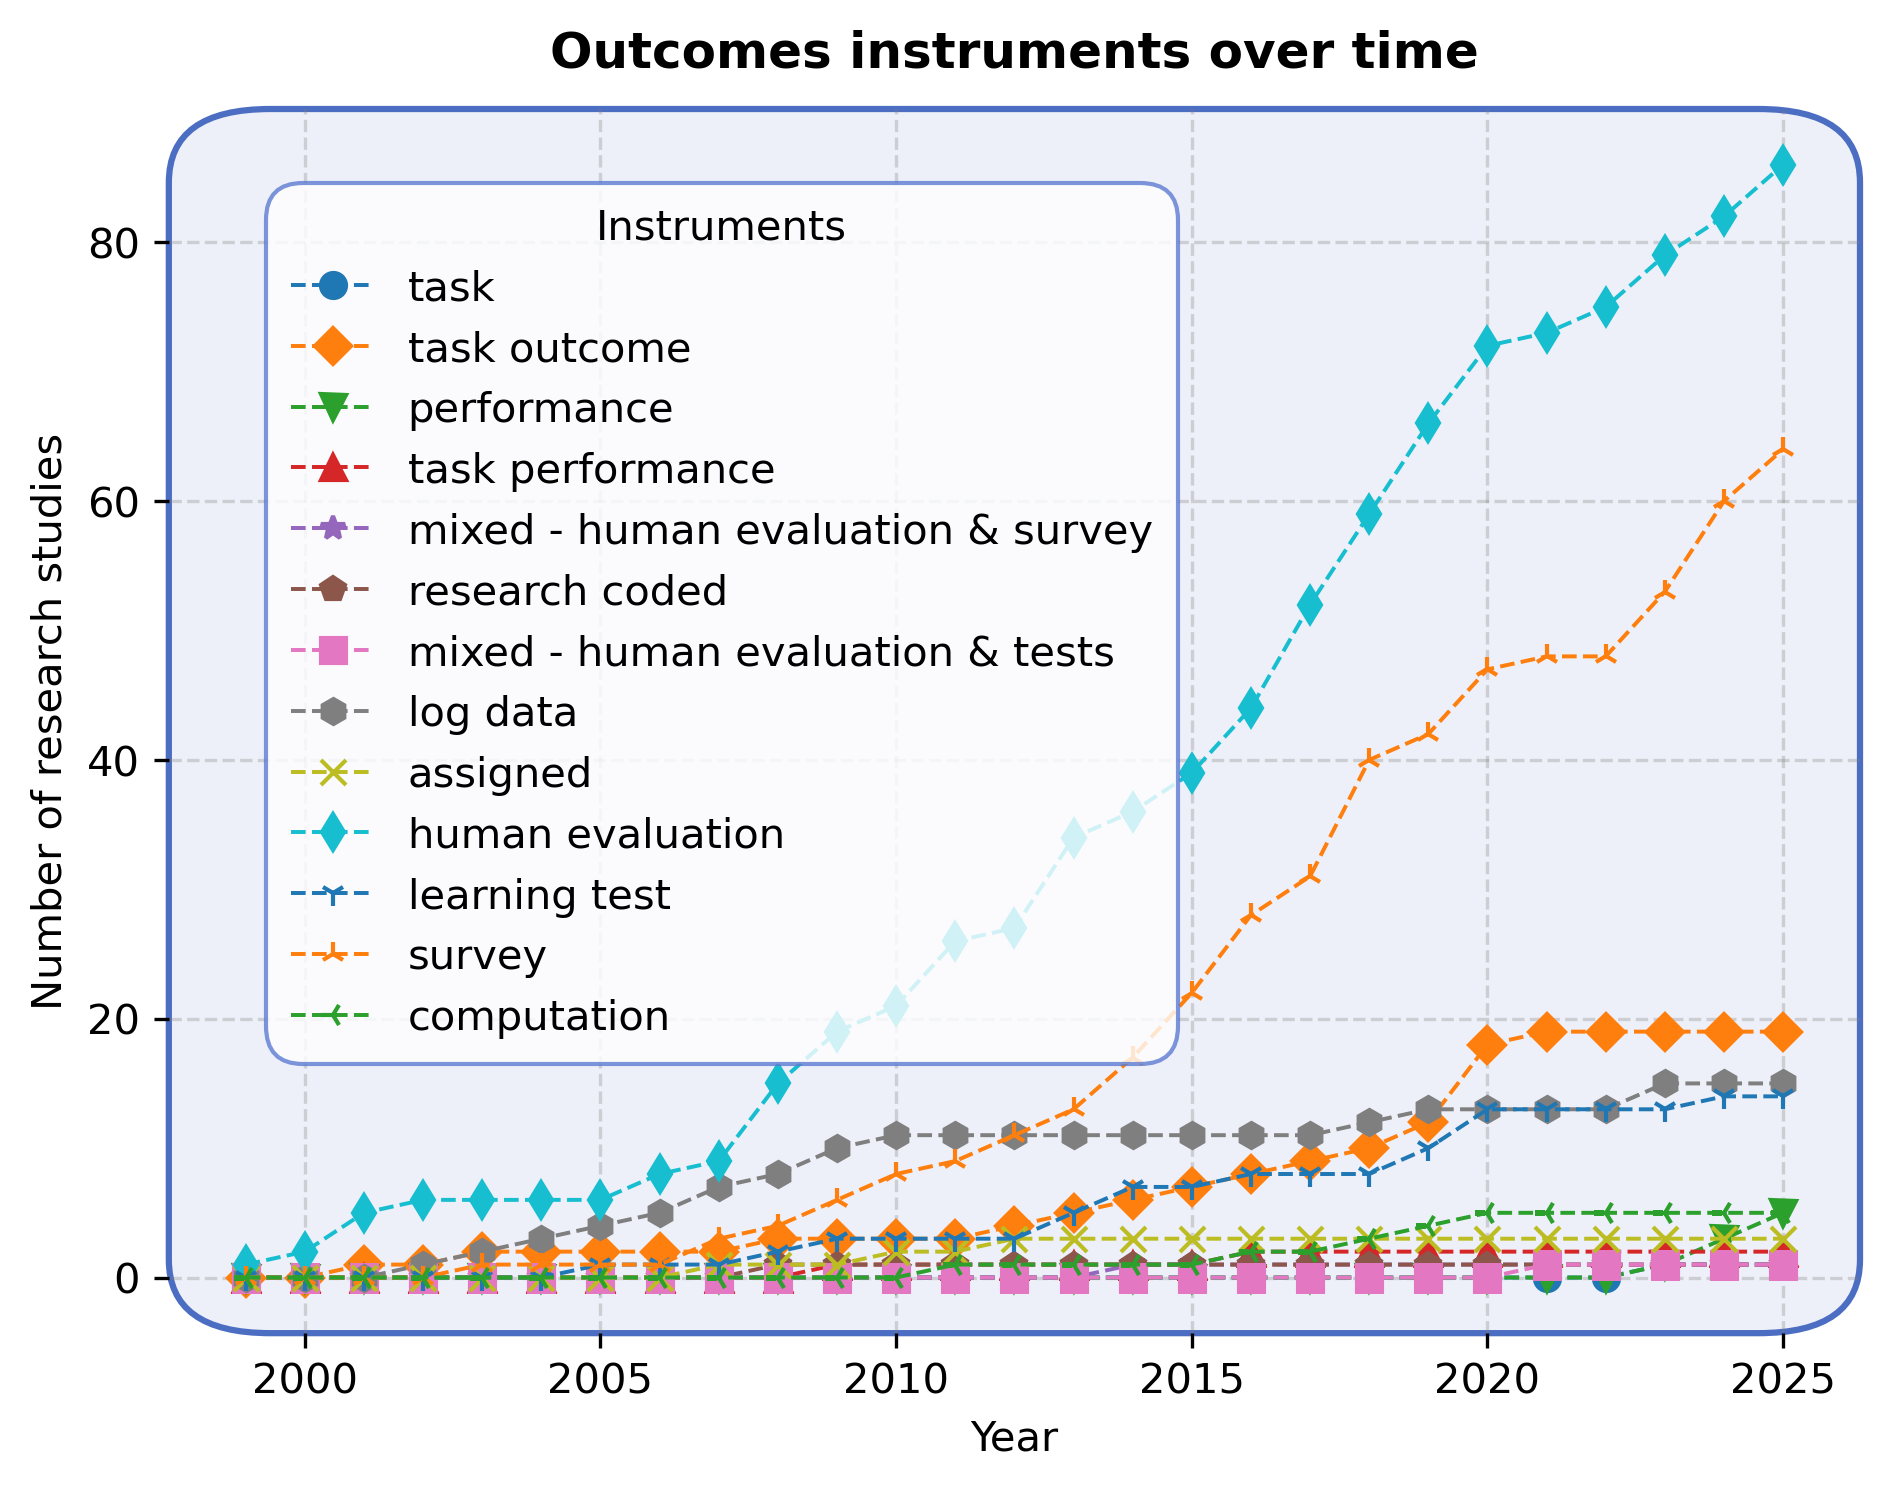

In [86]:
data_ = lit.plot_trends('outcomes_sm', fig_title="Outcomes (smaller) explored over time",attribute_label="Outcomes")
lit.plot_trends('outcomes_lg',fig_title="Outcomes (larger categories) explored over time",attribute_label="Outcomes")
lit.plot_trends('outcomes_instrument',fig_title="Outcomes instruments over time",attribute_label="Instruments")

In [13]:
import matplotlib.patches as mpatches
import matplotlib.axes as axes
from matplotlib.projections import register_projection
import matplotlib.pyplot as plt

class StaticColorAxisBBox(mpatches.FancyBboxPatch):
    def set_edgecolor(self, color):
        if hasattr(self, "_original_edgecolor"):
            return
        self._original_edgecolor = color
        self._set_edgecolor(color)

    def set_linewidth(self, w):
        super().set_linewidth(1.5)


class FancyAxes(axes.Axes):
    name = "fancy_box_axes"
    _edgecolor: str

    def __init__(self, *args, **kwargs):
        self._edgecolor = kwargs.pop("edgecolor", None)
        super().__init__(*args, **kwargs)

    def _gen_axes_patch(self):
        return StaticColorAxisBBox(
            (0, 0),
            1.0,
            1.0,
            boxstyle="round, rounding_size=0.06, pad=0",
            edgecolor=self._edgecolor,
            linewidth=5,
        )

register_projection(FancyAxes)
fig, ax = plt.subplots(subplot_kw={'projection': 'fancy_box_axes'})
ax.plot([-1, 1, 1], [-1, -1, 1], "o-")
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)

/var/folders/66/x_8szp093m33zpwn1prczj780000gn/T/ipykernel_6970/2469118445.py:37: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([-1, 1, 1], [-1, -1, 1], "o-",label="x",linestyle='--')
/var/folders/66/x_8szp093m33zpwn1prczj780000gn/T/ipykernel_6970/2469118445.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "*-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([-1, 1, 1], [-1, -1, -1], "*-",label="y",linestyle='--')


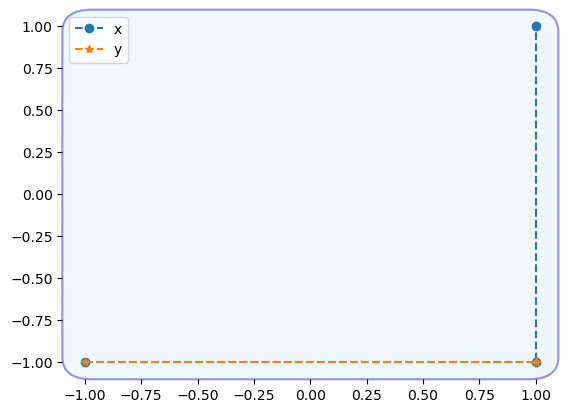

In [31]:
import matplotlib.patches as mpatches
import matplotlib.axes as axes
from matplotlib.projections import register_projection


class StaticColorAxisBBox(mpatches.FancyBboxPatch):
    def set_edgecolor(self, color):
        if hasattr(self, "_original_edgecolor"):
            return
        self._original_edgecolor = color
        self._set_edgecolor(color)

    def set_linewidth(self, w):
        super().set_linewidth(1.5)


class FancyAxes(axes.Axes):
    name = "fancy_box_axes"
    _edgecolor: str

    def __init__(self, *args, **kwargs):
        self._edgecolor = kwargs.pop("edgecolor", None)
        super().__init__(*args, **kwargs)

    def _gen_axes_patch(self):
        return StaticColorAxisBBox(
            (0, 0),
            1.0,
            1.0,
            boxstyle="round, rounding_size=0.06, pad=0",
            edgecolor='#8F92E8',
            linewidth=5,
        )

register_projection(FancyAxes)
fig, ax = plt.subplots(subplot_kw={'projection': 'fancy_box_axes'})
ax.plot([-1, 1, 1], [-1, -1, 1], "o-",label="x",linestyle='--')
ax.plot([-1, 1, 1], [-1, -1, -1], "*-",label="y",linestyle='--')
ax.set_facecolor("#F1F8FD")
ax.spines[["bottom", "left", "right", "top"]].set_visible(False)
ax.legend().get_frame().set_boxstyle('Round', pad=0.6, rounding_size=4)
plt.legend()

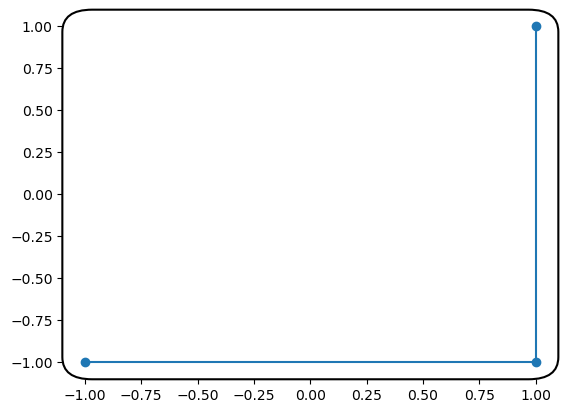

In [9]:
x1

0.8891493055555556